In [1]:
import torch

## Linear Model
model = torch.nn.Linear(10,1)

x = torch.randn(20,10)
y = torch.randn(20,1)

print(f'{x=} {y=}', x, y)

pred_y = model(x)
print(pred_y)

# Compare y and predicted by model pred_y
loss = torch.nn.functional.mse_loss(pred_y,y)
print(loss)

def mse_loss(y, pred_y):
    return torch.mean((y - pred_y)**2)

mse_loss(y, pred_y)


x=tensor([[ 0.5851,  0.4539, -0.1732, -0.4928, -1.0216, -0.1073,  1.2028, -0.2060,
          0.5746,  0.1979],
        [-1.6087,  2.3403, -0.3891, -0.8451, -0.2541,  1.8848,  0.6446,  1.7112,
          0.9846, -0.9857],
        [ 1.0086, -0.0600, -0.7814,  0.1879,  0.3777, -0.9208, -0.3408, -0.3451,
          1.5222,  0.3070],
        [-1.7415, -1.1855, -2.8430,  1.8541, -1.0794,  0.5337,  0.8545,  1.4112,
          0.8361, -0.6132],
        [-0.0573, -1.4929,  0.2637,  1.2287,  0.0963, -0.3517,  1.5230, -1.8512,
          1.8838,  1.5169],
        [ 0.5841, -0.0111,  1.9227,  0.8524, -0.5711, -0.2806, -1.4079,  1.2432,
         -0.1304,  1.4363],
        [-0.2412, -0.8949,  1.0973, -1.0415, -1.0193, -0.4889,  1.0833, -0.1501,
         -1.2475, -1.6336],
        [ 1.4329, -0.6351, -0.5455,  0.5785, -0.8591,  0.4339, -2.0395,  0.7103,
         -0.6373, -1.3216],
        [-0.1709,  0.8460,  0.5840, -0.5351, -0.1409,  1.1247, -1.2101, -0.8133,
         -0.3857, -0.8237],
        [ 0.6011,

tensor(1.0690, grad_fn=<MeanBackward0>)

Binary Classification

In [6]:
y = (torch.randn(20,1)>0).float()
print(y)

tensor([[0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.]])


In [7]:
loss = torch.nn.functional.binary_cross_entropy_with_logits(pred_y, y)
print(loss)

tensor(0.6991, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


Multiclass Classifiation

In [15]:
n_classes = 3
model = torch.nn.Linear(10,n_classes)

# Adding two times so we can get values as 0,1 and 2 for the 3 classes
y = (torch.randn(20) > 0).int() + (torch.randn(20) > 0).int()
print(y)
print(y.squeeze())

tensor([2, 1, 1, 1, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 2, 0, 0, 1, 1, 1],
       dtype=torch.int32)
tensor([2, 1, 1, 1, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 2, 0, 0, 1, 1, 1],
       dtype=torch.int32)


In [20]:
pred_y = model(x)
loss = torch.nn.functional.cross_entropy(pred_y, y.squeeze().long())
print(loss)

tensor(1.0214, grad_fn=<NllLossBackward0>)



# Optimizer

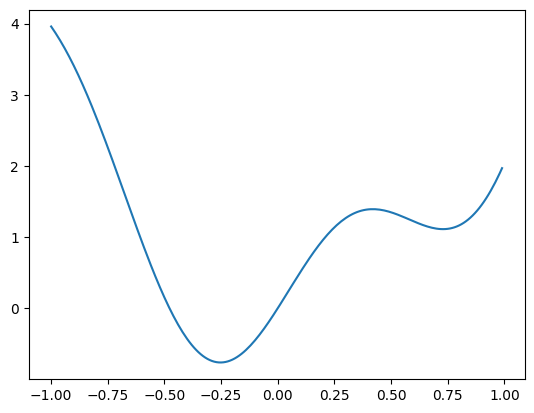

In [37]:
import matplotlib.pyplot as plt
import torch

def f(x: torch.Tensor) -> torch.Tensor:
    return 3*x**2 + torch.sin(5*x)

#Calculate gradient
def grad_f(x: torch.tensor) -> torch.Tensor:
    return 6*x + 5*torch.cos(5*x)

plt.plot(torch.arange(-1,1,0.01), f(torch.arange(-1,1,0.01)))

tensor([0.6605])
tensor([0.7293])
tensor([0.6702]) tensor([0.7293])


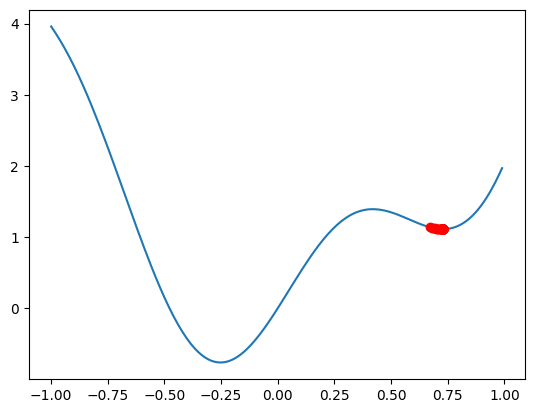

In [47]:
x = torch.randn(1)
print(x)
#plt.plot(torch.arange(-1,1,0.01), f(torch.arange(-1,1,0.01)))

all_x =[]
for _ in range(100):
    x = x-0.01* grad_f(x)
    all_x.append(x)
print(x)
plt.plot(torch.arange(-1,1,0.01), f(torch.arange(-1,1,0.01)))
plt.plot(torch.stack(all_x), f(torch.stack(all_x)), 'ro')
print(all_x[0], all_x[-1])

# Computational Graphs

In [51]:
y = torch.rand(10, requires_grad=False)
x = torch.rand(10, requires_grad=True)

y
x

tensor([0.3960, 0.4369, 0.0931, 0.0091, 0.5899, 0.8336, 0.0161, 0.9250, 0.6482,
        0.7969], requires_grad=True)

In [78]:
a = y**2
print(a)

# Has a grad function attached even on a function with requires grad is originally true.  It starts building a computational graph
# It calculated the gradient using mean of the tensor and then backpropagated it
b = (x**2).mean()
print(b)
print(x.grad)
b.backward()



tensor([0.0213, 0.4927, 0.4058, 0.1068, 0.0519, 0.1892, 0.9180, 0.3928, 0.1364,
        0.0639])
tensor(0.3310, grad_fn=<MeanBackward0>)
tensor([1.1087, 1.2232, 0.2606, 0.0255, 1.6517, 2.3340, 0.0449, 2.5900, 1.8149,
        2.2313])


In [79]:
# Both are same. Mean means diving by 10 and srquare means multiplying by 2. 
print(x / 10 * 2)
print(x.grad)

#cannot call backward again here, need to define a new variable or redefine b
# b.backward()

tensor([0.0792, 0.0874, 0.0186, 0.0018, 0.1180, 0.1667, 0.0032, 0.1850, 0.1296,
        0.1594], grad_fn=<MulBackward0>)
tensor([1.1879, 1.3106, 0.2792, 0.0273, 1.7696, 2.5007, 0.0482, 2.7750, 1.9446,
        2.3907])


# Linear Regression in Pytorch

In [ ]:
# Working with a dataset here

